# Import libraries

In [8]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

# Load Dataset

In [10]:
unemployment = pd.read_csv("Employment_Unemployment_GDP_data.csv")

In [11]:
unemployment

,Country Name,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (in USD)
0,Albania,1991,53.299533,12.172764,34.527781,10.304,1.099559e+09
1,Algeria,1991,24.118566,25.067734,50.813700,20.600,4.571568e+10
2,Angola,1991,40.071857,8.163345,51.764822,16.855,1.060378e+10
3,Argentina,1991,13.669999,28.505903,57.824098,5.440,1.897200e+11
4,Armenia,1991,54.263252,15.790454,29.946294,1.783,2.069870e+09
...,...,...,...,...,...,...,...
5746,Viet Nam,2022,33.609304,30.611964,35.778734,1.523,4.134452e+11
5747,Virgin Islands (U.S.),2022,1.293486,15.193240,83.513274,13.007,4.672000e+09
5748,West Bank and Gaza,2022,6.220994,32.609239,61.169768,24.420,1.916550e+10
5749,Zambia,2022,57.314602,10.346079,32.339318,5.995,2.916378e+10


# Dataset Information

In [20]:
unemployment.shape

(5751, 7)

In [22]:
unemployment.describe()

,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (in USD)
count,5751.000000,5751.000000,5751.000000,5751.000000,5751.000000,5.751000e+03
mean,2006.568945,28.857051,19.773784,51.369166,8.155004,3.099333e+11
std,9.175548,24.026669,8.606954,18.892155,6.147428,1.375556e+12
min,1991.000000,0.107774,2.060372,5.314014,0.100000,7.228540e+07
25%,1999.000000,7.173214,13.889285,36.846735,3.659000,5.098458e+09
50%,2007.000000,22.172104,20.105516,52.657618,6.358000,1.972356e+10
75%,2014.000000,46.130703,25.345213,66.602313,10.996000,1.277237e+11
max,2022.000000,92.482036,59.579079,93.416932,38.800000,2.600689e+13


# Check Missing Values

In [21]:
unemployment.isnull().sum()


Country Name                      0
Year                              0
Employment Sector: Agriculture    0
Employment Sector: Industry       0
Employment Sector: Services       0
Unemployment Rate                 0
GDP (in USD)                      0
dtype: int64

## Checking Data Types of Dataset

In [23]:
unemployment.dtypes

Country Name                       object
Year                                int64
Employment Sector: Agriculture    float64
Employment Sector: Industry       float64
Employment Sector: Services       float64
Unemployment Rate                 float64
GDP (in USD)                      float64
dtype: object

filter_data= unemployment[["Country Name","Employment Sector: Agriculture","Unemployment Rate","GDP (in USD)"]]

## Filtering Required Columns

In [24]:
filter_data = unemployment[["Country Name","Employment Sector: Agriculture","Unemployment Rate","GDP (in USD)"]]

In [25]:
filter_data

,Country Name,Employment Sector: Agriculture,Unemployment Rate,GDP (in USD)
0,Albania,53.299533,10.304,1.099559e+09
1,Algeria,24.118566,20.600,4.571568e+10
2,Angola,40.071857,16.855,1.060378e+10
3,Argentina,13.669999,5.440,1.897200e+11
4,Armenia,54.263252,1.783,2.069870e+09
...,...,...,...,...
5746,Viet Nam,33.609304,1.523,4.134452e+11
5747,Virgin Islands (U.S.),1.293486,13.007,4.672000e+09
5748,West Bank and Gaza,6.220994,24.420,1.916550e+10
5749,Zambia,57.314602,5.995,2.916378e+10


# Remove Duplicates

In [31]:
unemployment.drop_duplicates

<bound method DataFrame.drop_duplicates of                Country Name  Year  Employment Sector: Agriculture  \
0                   Albania  1991                       53.299533   
1                   Algeria  1991                       24.118566   
2                    Angola  1991                       40.071857   
3                 Argentina  1991                       13.669999   
4                   Armenia  1991                       54.263252   
...                     ...   ...                             ...   
5746               Viet Nam  2022                       33.609304   
5747  Virgin Islands (U.S.)  2022                        1.293486   
5748     West Bank and Gaza  2022                        6.220994   
5749                 Zambia  2022                       57.314602   
5750               Zimbabwe  2022                       52.610143   

      Employment Sector: Industry  Employment Sector: Services  \
0                       12.172764                    34.527781

# Unemployment Rate Distribution

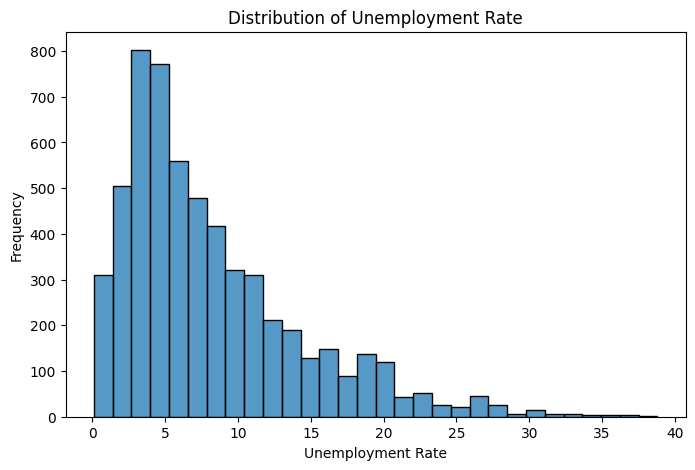

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(unemployment['Unemployment Rate'], bins=30)
plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate")
plt.ylabel("Frequency")
plt.show()

# Average Unemployment by Year

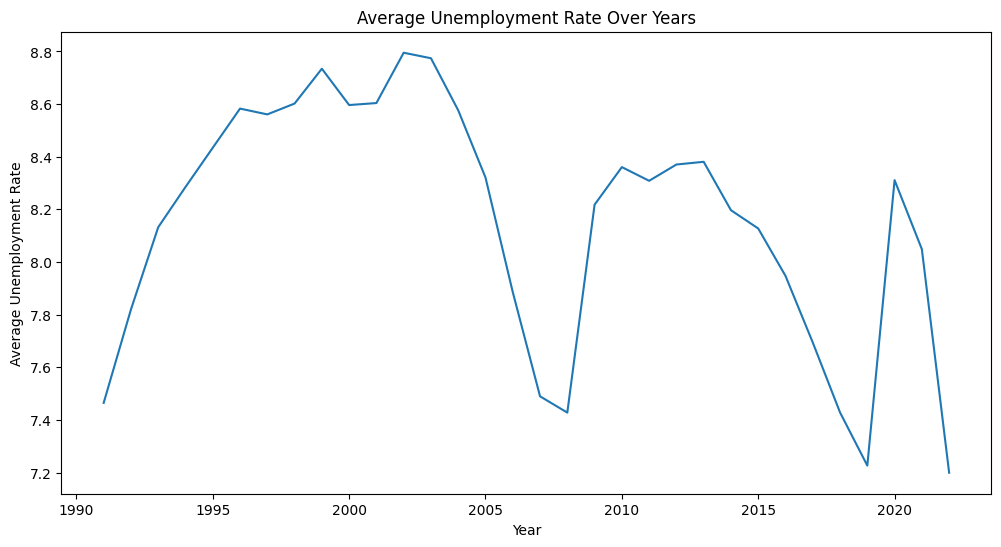

In [25]:
yearly_unemployment = unemployment.groupby('Year')['Unemployment Rate'].mean()
plt.figure(figsize=(12,6))
plt.plot(yearly_unemployment.index,
         yearly_unemployment.values)
plt.title("Average Unemployment Rate Over Years")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate")
plt.show()

# GDP vs Unemployment

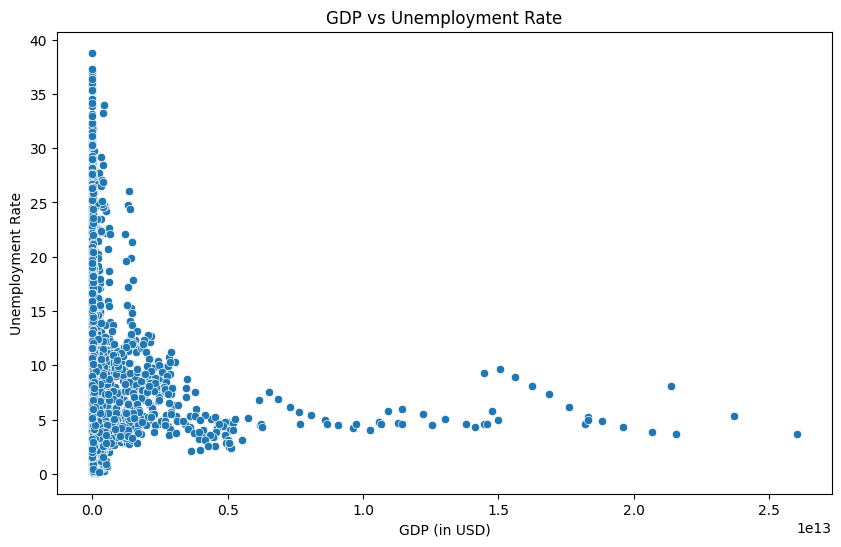

In [26]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='GDP (in USD)',
    y='Unemployment Rate',
    data=unemployment
)
plt.title("GDP vs Unemployment Rate")
plt.show()

# Correlation Analysis

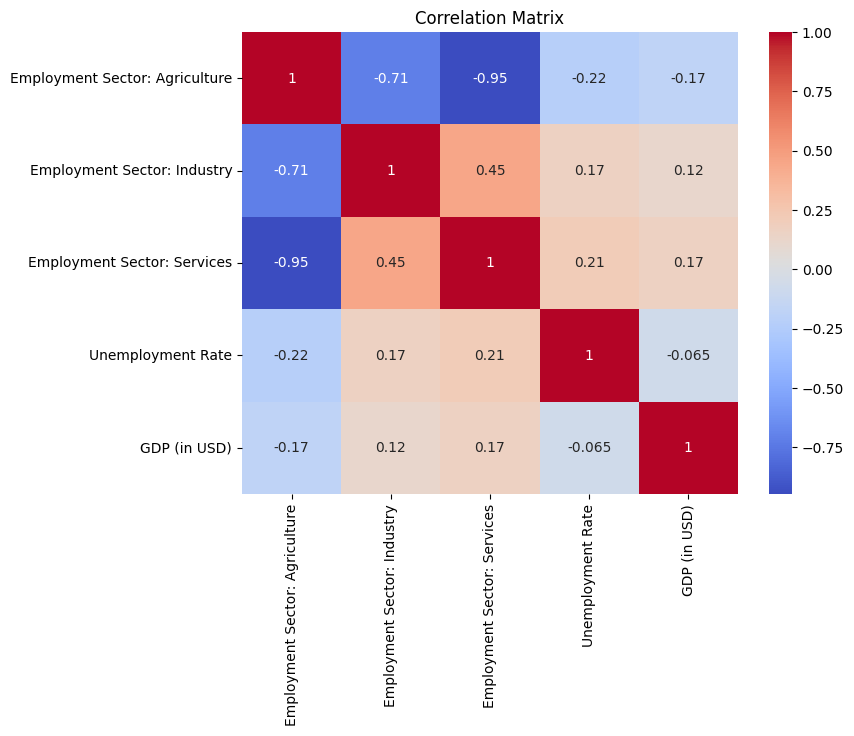

In [27]:
corr = unemployment[['Employment Sector: Agriculture',
           'Employment Sector: Industry',
           'Employment Sector: Services',
           'Unemployment Rate',
           'GDP (in USD)']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Top 10 Countries with Highest Unemployment 

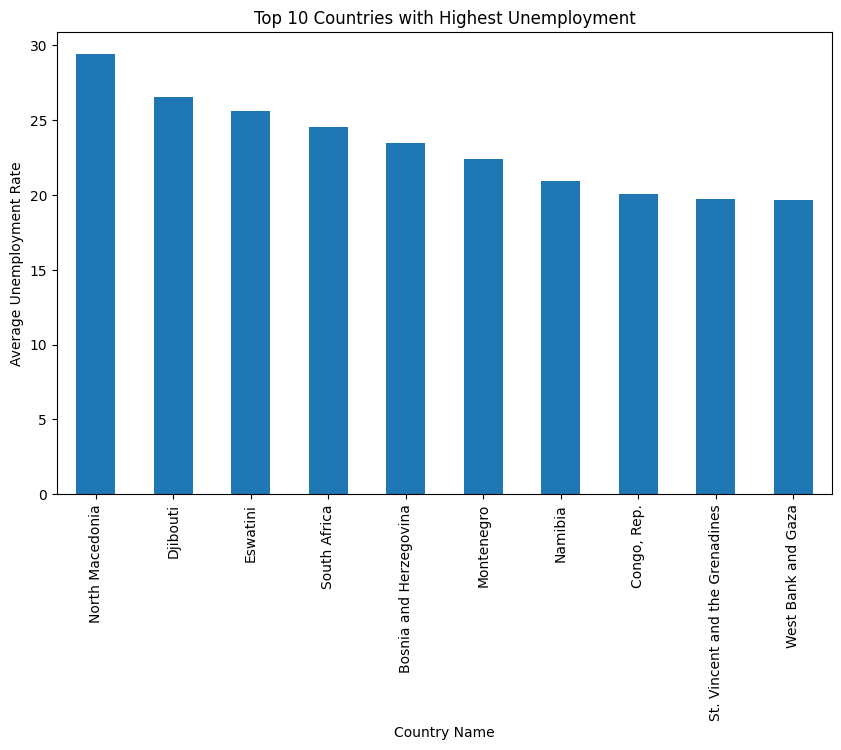

In [28]:
country_unemployment = unemployment.groupby(
    'Country Name'
)['Unemployment Rate'].mean()
top10 = country_unemployment.sort_values(
    ascending=False
).head(10)
plt.figure(figsize=(10,6))
top10.plot(kind='bar')
plt.title("Top 10 Countries with Highest Unemployment")
plt.ylabel("Average Unemployment Rate")
plt.show()

# COVID-19 Impact Analysis

Before vs During COVID 

In [23]:
before_covid = unemployment[unemployment['Year'] < 2020]['Unemployment Rate'].mean()
during_covid = unemployment[unemployment['Year'] >= 2020]['Unemployment Rate'].mean()
print("Before COVID:", before_covid)
print("During COVID:", during_covid)

Before COVID: 8.185696952271421
During COVID: 7.85514606741573


# Visualization

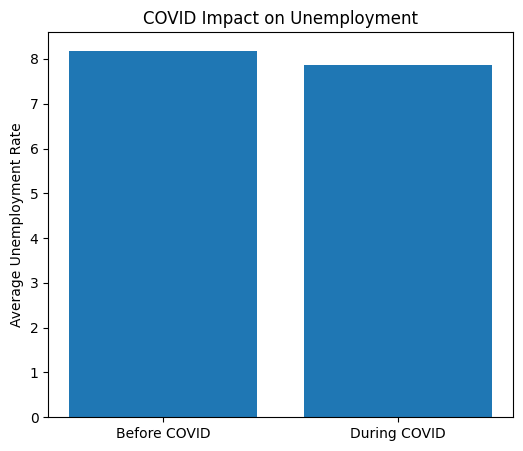

In [29]:
covid_data = {
    "Before COVID": before_covid,
    "During COVID": during_covid
}
plt.figure(figsize=(6,5))
plt.bar(
    covid_data.keys(),
    covid_data.values()
)
plt.title("COVID Impact on Unemployment")
plt.ylabel("Average Unemployment Rate")
plt.show()